In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
inputFiles = [
    '../volume_0.01/greitzer_dynamics.csv',
    '../volume_0.1/greitzer_dynamics.csv',
    '../volume_1/greitzer_dynamics.csv',
    '../volume_10/greitzer_dynamics.csv',
]

labels = [
    r'$V_{\rm pl}=0.01 \ m^3$',
    r'$V_{\rm pl}=0.1 \ m^3$',
    r'$V_{\rm pl}=1 \ m^3$',
    r'$V_{\rm pl}=10 \ m^3$',
    ]

ls = ['-', '--', '-.', ':']
lw = 2

datasets = []
for inputFile in inputFiles:
    data = pd.read_csv(inputFile)
    datasets.append(data)

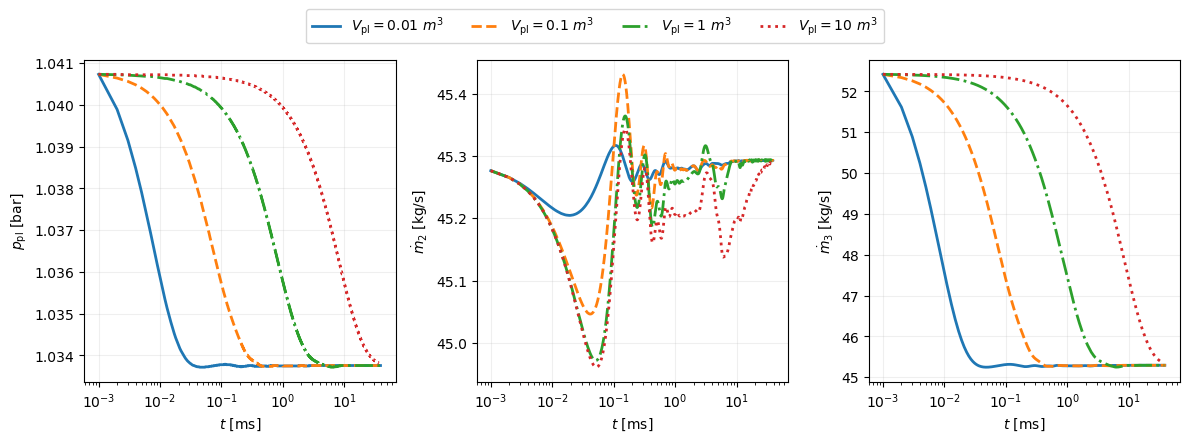

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for idata, data in enumerate(datasets):
    time = data["Time[s]"][1:]
    plenumPressure = data["PlenumPressure[Pa]"][1:]
    plenumInletMassflow = data["PlenumInletMassflow[kg/s]"][1:]
    plenumOutletMassflow = data["PlenumOutletMassflow[kg/s]"][1:]
    
    axes[0].plot(time*1E3, plenumPressure/1E5, label = labels[idata], linestyle=ls[idata], linewidth=lw)
    axes[1].plot(time*1E3, plenumInletMassflow, '%sC%i' % (ls[idata], idata), linewidth=lw)
    axes[2].plot(time*1E3, plenumOutletMassflow, '%sC%i' % (ls[idata], idata), linewidth=lw)
    
for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlabel(r'$t \ \rm{[ms]}$')
axes[0].set_ylabel(r'$p_{\rm pl}$ [bar]')
axes[1].set_ylabel(r'$\dot{{m}}_{2}$ [kg/s]')
axes[2].set_ylabel(r'$\dot{{m}}_{3}$ [kg/s]')
fig.legend(loc='upper center', ncol=len(inputFiles), bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()

for ax in axes:
    ax.set_xscale('log')
    
plt.savefig("greitzer_dynamics.pdf", bbox_inches='tight')